In [ ]:
import matplotlib
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import numpy as np

In [2]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

matplotlib.rc("font", size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc("axes", titlesize=MEDIUM_SIZE)     # fontsize of the axes title
matplotlib.rc("axes", labelsize=SMALL_SIZE)    # fontsize of the x and y labels
matplotlib.rc("xtick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("ytick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("legend", fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc("figure", titlesize=MEDIUM_SIZE)  # fontsize of the figure title

In [3]:
def antenna(theta, phi, psi, gamma):
    F_plus = np.sin(gamma)/2 * ((1+np.cos(theta)**2)*np.cos(2*phi)*np.cos(2*psi) 
                                - 2*np.cos(theta)*np.sin(2*phi)*np.sin(2*psi))
    F_cross = np.sin(gamma)/2 * ((1+np.cos(theta)**2)*np.cos(2*phi)*np.sin(2*psi) 
                                 + 2*np.cos(theta)*np.sin(2*phi)*np.cos(2*psi))
    return (F_plus, F_cross)

In [4]:
def antenna_plot(theta, phi, r, vmax=None, label = None, save_as = None):
    theta_grid, phi_grid = np.meshgrid(theta.flatten(), phi.flatten(), indexing="ij")
    x = r * np.sin(theta_grid) * np.cos(phi_grid)
    y = r * np.sin(theta_grid) * np.sin(phi_grid)
    z = r * np.cos(theta_grid)
    cmap = matplotlib.cm.get_cmap("jet")
    norm = Normalize(vmin=0, vmax=np.max(r) if vmax is None else vmax)
    color = cmap(norm(r))
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(5/2.54, 9/2.54))
    ax.plot_surface(x, y, z, facecolors=color)
    mappable = ScalarMappable(cmap=cmap, norm=norm)
    mappable.set_array(r)
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.3)
    if label is not None: ax.set_title(label)
    ax.set_xlim(-0.75, 0.75)
    ax.set_ylim(-0.75, 0.75)
    ax.set_zlim(-1, 1)
    ax.set_aspect("equal")
    ax.set_xticks([-0.5, 0, 0.5])
    ax.set_yticks([-0.5, 0, 0.5])
    ax.set_zticks([-0.5, 0, 0.5])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.view_init(elev=30, azim=60)  
    fig.tight_layout()
    if save_as is not None:
        fig.savefig(save_as, bbox_inches="tight", dpi=300)

/tmp/ipykernel_9098/253884004.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap("jet")


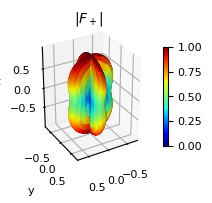

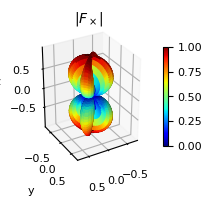

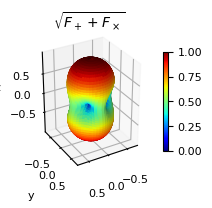

In [40]:
N = 200
theta = np.linspace(0, np.pi, N)[:,np.newaxis]
phi = np.linspace(0, 2*np.pi, N)[np.newaxis,:]
F = antenna(theta, phi, psi=0, gamma=np.pi/2)
antenna_plot(theta, phi, np.abs(F[0]), vmax=1, label=r"$|F_+|$")
antenna_plot(theta, phi, np.abs(F[1]), vmax=1, label=r"$|F_\times|$")
antenna_plot(theta, phi, np.sqrt(F[0]**2 + F[1]**2), vmax=1, label=r"$\sqrt{F_+ + F_\times}$")

/tmp/ipykernel_9098/1849286550.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap("jet")


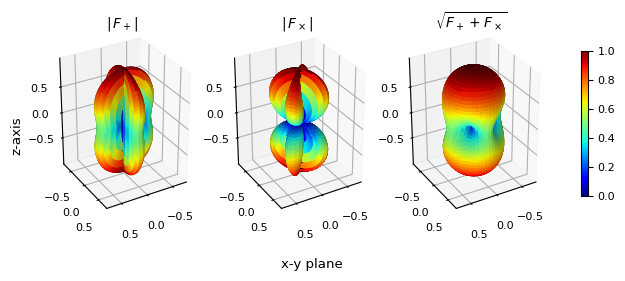

In [41]:
fig, axs = plt.subplots(ncols=4, subplot_kw={"projection": "3d"}, width_ratios=[0.3,0.3,0.3,0.05], figsize=(16/2.54, 7/2.54))

theta_grid, phi_grid = np.meshgrid(theta.flatten(), phi.flatten(), indexing="ij")
r = [np.abs(F[0]), np.abs(F[1]), np.sqrt(F[0]**2 + F[1]**2)]
titles = [r"$|\,F_+|$", r"$|\,F_\times|$", r"$\sqrt{F_+ + F_\times}$"]
for i, _ in enumerate(r):
    x = r[i] * np.sin(theta_grid) * np.cos(phi_grid)
    y = r[i] * np.sin(theta_grid) * np.sin(phi_grid)
    z = r[i] * np.cos(theta_grid)
    cmap = matplotlib.cm.get_cmap("jet")
    norm = Normalize(vmin=0, vmax=1)
    color = cmap(norm(r[i]))
    axs[i].plot_surface(x, y, z, facecolors=color, antialiased=True)
    axs[i].set_xlim(-0.75, 0.75)
    axs[i].set_ylim(-0.75, 0.75)
    axs[i].set_zlim(-1, 1)
    axs[i].set_aspect("equal")
    axs[i].set_xticks([-0.5, 0, 0.5])
    axs[i].set_yticks([-0.5, 0, 0.5])
    axs[i].set_zticks([-0.5, 0, 0.5])
    axs[i].view_init(elev=30, azim=60)  
    axs[i].set_title(titles[i])

fig.supxlabel("x-y plane")
fig.supylabel("z-axis")
mappable = ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array(r)
cbar = fig.colorbar(mappable, ax=axs[-1], fraction=0.25)
axs[-1].set_axis_off()
fig.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)
fig.savefig("antenna.png", bbox_inches="tight", dpi=300)

/tmp/ipykernel_239706/253884004.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("jet")


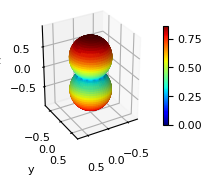

In [122]:
N = 100
theta = np.linspace(0, np.pi, N)[:,np.newaxis]
phi = np.linspace(0, 2*np.pi, N)[np.newaxis,:]
F1 = antenna(theta, phi, psi=0, gamma=np.pi/3)
F2 = antenna(theta, phi-2*np.pi/3, psi=0, gamma=np.pi/3)
F3 = antenna(theta, phi-4*np.pi/3, psi=0, gamma=np.pi/3)
antenna_plot(theta, phi, (np.sqrt(F1[0]**2 + F1[1]**2)+np.sqrt(F2[0]**2 + F2[1]**2)+np.sqrt(F3[0]**2 + F3[1]**2))/3)